In [59]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import cv2
import numpy as np
from PIL import Image
from sqlalchemy import create_engine

# 폰트 설정
font_path = 'C:\Windows\Fonts\gulim.ttc' 
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()

In [60]:
# DB 연결 정보 설정
DB_USER = 'farmorai_admin'
DB_PASSWORD = 'farmorai12345'
DB_HOST = '192.168.0.4'  # 또는 특정 IP
DB_PORT = '3306'         # 포트 번호
DB_NAME = 'farmdb'

# SQLAlchemy 엔진 생성
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

# SQL 쿼리 작성 및 DataFrame으로 변환
sql = "SELECT * FROM apple_label_dataset"
df = pd.read_sql(sql, engine)

In [61]:
# 이미지 전처리 함수
def preprocess(image):
   image = np.array(image)

   # 1. 이미지 크기 조정
   image = cv2.resize(image, (224, 224))

   # 2. CLAHE 적용 (대비 향상)
   lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)  # 이미지를 RGB에서 LAB 색 공간으로 변환
   l, a, b = cv2.split(lab)                      # LAB 이미지에서 L(밝기), A(색상 정보), B(색상 정보) 채널을 분리
   clahe = cv2.createCLAHE(
      clipLimit=2.0, tileGridSize=(8, 8)
   )                                             # 이미지 블록을 8x8로 나눠서 각 블록에 대해 히스토그램 평활화 적용
   l = clahe.apply(l)                            # 명도 정보를 부분별로 보정해, 어두운 곳은 더 밝게, 밝은 곳은 더 어둡게 보정
   lab = cv2.merge((l, a, b))                    # CLAHE가 적용된 l 채널과 원래의 a, b 채널을 다시 합쳐서 LAB 이미지
   image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

   # 3. 샤프닝 필터 정의 (일반적인 샤프닝 커널)
   # mask = np.asarray([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype = np.float32)
   # image = cv2.filter2D(image, -1, mask)

   # 4. 이미지 정규화
   image = image.astype(np.float32) / 255.0

   # 5. 배치 차원 추가
   # 모델의 입력은 batch 단위로 처리되기 때문에, 
   # 단일 이미지를 모델에 전달하려면 batch_size=1로 설정해줘야 합니다.
   # 모델이 여러 개의 샘플을 처리하는 방식을 기대하는데, 
   # 단일 이미지 데이터를 제공하면 오류가 발생할 수 있습니다.
   # (224, 224, 3) -> (1, 224, 224, 3) 
   image = np.expand_dims(image, axis=0)
   return image

(1, 224, 224, 3)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

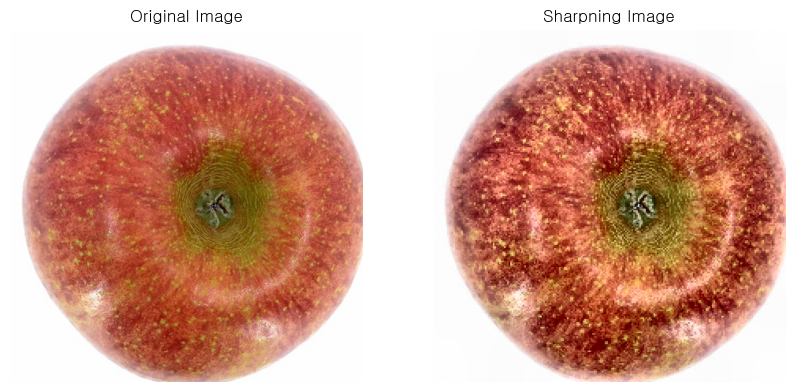

In [58]:
zip_file_path = '../../apple_data/image_data.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
   image_file_name = df['file_name'][0]
   
   with zip_ref.open(image_file_name) as img_file:
      image = Image.open(img_file)
      sharp_img = preprocess(image)

print(sharp_img.shape)

# 시각화
plt.figure(figsize=(10, 5))  # 원하는 크기로 수정 가능

# 원본 이미지
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

# 샤프닝된 이미지
plt.subplot(1, 2, 2)
plt.imshow(sharp_img[0])  # 샤프닝 후 이미지
plt.title('Sharpning Image')
plt.axis('off')

In [44]:
zip_file_path = '../../apple_data/image_data.zip'
img_data = []
label_to_names = {'특':0, '상':1, '보통':2}
label_data = []

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
   for _, file in df.iterrows():
      with zip_ref.open(file['file_name']) as img_file:
         # 이미지 파일을 ByteIO로 읽어와 OpenCV로 읽기
         img_bytes = img_file.read()
         img_array = np.frombuffer(img_bytes, np.uint8)
         image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

         # 이미지 전처리 및 데이터 추가
         image_ps = preprocess(image)
         img_data.append(image_ps)

         # 이미지 라벨 데이터 추가
         label_name = label_to_names.get(file['cate3'])
         label_data.append(label_name)

# 리스트를 numpy 배열로 변환
img_data_array = np.array(img_data)
label_data_array = np.array(label_data)

# 파일로 저장
np.save('apple_images.npy', img_data_array)
np.save('apple_labels.npy', label_data_array)

print(f'이미지 데이터 저장 완료: {img_data_array.shape}')
print(f'레이블 데이터 저장 완료: {label_data_array.shape}')

이미지 데이터 저장 완료: (1564, 224, 224, 3)
레이블 데이터 저장 완료: (1564,)


In [38]:
df_main = pd.DataFrame({'image': img_data, 'label': label_data})
df_main.to_sql('apple_main_dataset', con=engine, if_exists='replace', index=False)

1564